<a href="https://colab.research.google.com/github/amrritt18/Class-work-/blob/main/DL_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Forward Propogation

In [30]:
import numpy as np

In [31]:
#adding training data
X = np.array([
    [0.5,-0.4],

])

y = np.array([
    [0.15],

])

In [32]:
#Sigmoid fn
def Sigmoid(x):
  fn = 1/(1+np.exp(-x))
  return fn

In [33]:
Sigmoid(5)

np.float64(0.9933071490757153)

In [34]:
# Sigmoid derivative
def Sigmoid_derivative(x):
  return x*(1-x)

In [35]:
def tansigmoid(x):
  return np.tanh(x)


In [36]:
def tanSigmoidDerivative(x):
  return 1-np.tanh(x)**2

In [37]:
W1 = np.array([
    [0.2,0.4,0.3],
    [0.1,0.6,0.5]
])
B1 = np.array([
    [0,0,0]
])
W2 = np.array([
    [0.1],
    [0.2],
    [0.1]
])
B2 = np.array([
    [0]
])

In [38]:
#Forward propagation
def Forward(X,W1,B1,W2,B2):

    # hidden layer
    Z1 = np.dot(X, W1) + B1
    A1 = Sigmoid(Z1)

    # output layer
    Z2 = np.dot(A1, W2) + B2
    A2 = np.tanh(Z2)

    return Z1, A1, Z2, A2

In [39]:
#Loss Function
def Loss(y,y_pred):
  return np.mean((y-y_pred)**2)

In [40]:
#Backward Propagation
def backward(X, y, Z1, A1, Z2, A2, W2):

    m = X.shape[0]

    # output layer
    dA2 = A2 - y
    dZ2 = dA2 * (1 - A2**2)   # tanh derivative

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # hidden layer
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (A1 * (1 - A1))   # sigmoid derivative

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [41]:
def update_params(W1,b1,W2,b2,dW1,db1,dW2,db2,lr):

    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1

    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    return W1, b1, W2, b2

In [45]:
epoch = 100
lr = 0.01

losses = []

for i in range(epoch):

    # forward pass
    Z1,A1,Z2,A2 = Forward(X,W1,B1,W2,B2)

    # compute loss
    loss = Loss(y,A2)
    losses.append(loss)

    # backpropagation
    dW1, db1, dW2, db2 = backward(X, y, Z1, A1, Z2, A2, W2)

    # update parameters
    W1,B1,W2,B2 = update_params(W1,B1,W2,B2,dW1,db1,dW2,db2,lr)


    print("Epoch:", i, "Loss:", loss)


Epoch: 0 Loss: 1.3019286424057714e-31
Epoch: 1 Loss: 1.3019286424057714e-31
Epoch: 2 Loss: 1.3019286424057714e-31
Epoch: 3 Loss: 1.1093356479670479e-31
Epoch: 4 Loss: 1.1093356479670479e-31
Epoch: 5 Loss: 1.1093356479670479e-31
Epoch: 6 Loss: 1.1093356479670479e-31
Epoch: 7 Loss: 1.1093356479670479e-31
Epoch: 8 Loss: 1.1093356479670479e-31
Epoch: 9 Loss: 1.1093356479670479e-31
Epoch: 10 Loss: 1.1093356479670479e-31
Epoch: 11 Loss: 1.1093356479670479e-31
Epoch: 12 Loss: 9.321500930834222e-32
Epoch: 13 Loss: 9.321500930834222e-32
Epoch: 14 Loss: 9.321500930834222e-32
Epoch: 15 Loss: 9.321500930834222e-32
Epoch: 16 Loss: 9.321500930834222e-32
Epoch: 17 Loss: 9.321500930834222e-32
Epoch: 18 Loss: 9.321500930834222e-32
Epoch: 19 Loss: 7.703719777548943e-32
Epoch: 20 Loss: 7.703719777548943e-32
Epoch: 21 Loss: 7.703719777548943e-32
Epoch: 22 Loss: 7.703719777548943e-32
Epoch: 23 Loss: 7.703719777548943e-32
Epoch: 24 Loss: 7.703719777548943e-32
Epoch: 25 Loss: 7.703719777548943e-32
Epoch: 26 

In [47]:
print("Updated W1:\n", W1)
print("Updated b1:\n", B1)

print("Updated W2:\n", W2)
print("Updated b2:\n", B2)


Updated W1:
 [[0.19968647 0.39934833 0.29968515]
 [0.10025082 0.60052134 0.50025188]]
Updated b1:
 [[-0.00062706 -0.00130334 -0.00062969]]
Updated W2:
 [[0.08611848]
 [0.18679552]
 [0.08685971]]
Updated b2:
 [[-0.02696052]]


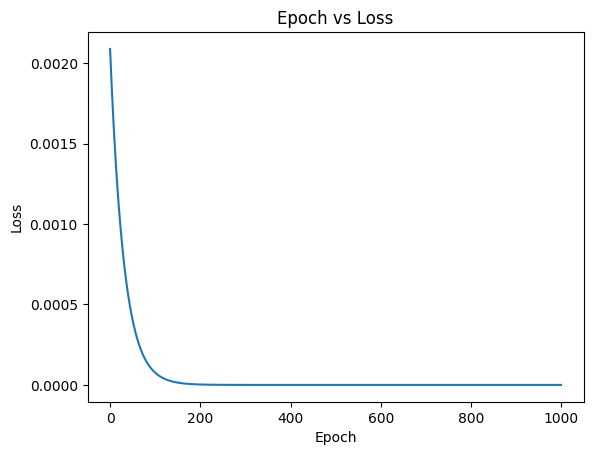

In [43]:
import matplotlib.pyplot as plt
plt.figure()

plt.plot(range(len(losses)), losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")

plt.show()